In [1]:
# %%

import typing as T
import pickle
import json
import os
import pathlib
import pathlib as P
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt

In [2]:
# %%

prj_path = str(P.Path("__file__").absolute().parent.parent.parent)
if prj_path not in sys.path:
  sys.path.append(prj_path)

In [3]:
# %%

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as ss
import seaborn as sns

In [4]:
# %%

import util.metrics as um
import sklearn.metrics as metrics

# %% [markdown]

 ##### load GO term mapping

In [5]:
# %%

ns = ['cc', 'mf', 'bp']
ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]

In [6]:
# %%

lable_path = [f"/data0/shaojiangyi/pprogo-flg-1/results/union_space_preds_only/{x}/test/union_go_terms.npy" for x in ns]
curr_labels = [np.load(p, allow_pickle=True).tolist() for p in lable_path]

namespace_terms = dict(zip(ontology_lst, curr_labels))

In [7]:
# %%

nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

# %% [markdown]

 ##### load count and ic

In [8]:
# %%

ci_path = "/data0/shaojiangyi/pprogo-flg-1/data/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(ci_path)

# %% [markdown]

 ##### eval by ic or count

# %% [markdown]

 ## preparing data

In [9]:
#%%

method_names = [
  "FINITE",
  "DeepGOPlus",
  "TALE",
  "DeepFRI",
  "DeepGraphGO",
  "PFresGO",
  "DPFunc",
]
method_predictions = clt.defaultdict(list)

In [11]:
single_pred_path = [f"/data0/shaojiangyi/pprogo-flg-1/results/fusion_runs_1/{x}/pred/{x}_test_probs.npy" for x in ns]
single_label_path = [f"/data0/shaojiangyi/pprogo-flg-1/results/union_space_preds_only1/{x}/test/union_labels.npy" for x in ns]

In [12]:
method_predictions["FINITE"] = [np.stack((np.load(l), np.load(p)), axis=0) 
                                for l, p in zip(single_label_path, single_pred_path)]

In [13]:
method_predictions["FINITE"][0].shape

(2, 268, 2881)

In [14]:
# %%

root_paths = [
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepgoplus/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-tale/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepfri/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-gcn",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-pfresgo/data-netgo",
    "/data0/shaojiangyi/dpfunc/netgo-results",
]

In [15]:
#%%

# load other methods
for root_path, method_name in zip(root_paths,
                                  method_names[1:]):
  pred_paths = [P.Path(root_path) / f"{ns[i]}_result_aligned.npy" for i in range(len(ns))]
  for i, pred_path in enumerate(pred_paths):
    if not pred_path.exists():
      print(f"File {pred_path} does not exist.")
      continue
    preds = np.load(pred_path)
    if preds.ndim == 1:
      preds = preds[:, None]
    # preds[0] = np.copy(method_predictions["FINITE"][i][0])
    # pring shape
    print(f"Method: {method_name}, Namespace: {ns[i]}, Shape: {preds.shape}")
    method_predictions[method_name].append(preds)

Method: DeepGOPlus, Namespace: cc, Shape: (2, 268, 2881)
Method: DeepGOPlus, Namespace: mf, Shape: (2, 505, 6860)
Method: DeepGOPlus, Namespace: bp, Shape: (2, 491, 21822)
Method: TALE, Namespace: cc, Shape: (2, 268, 2881)
Method: TALE, Namespace: mf, Shape: (2, 505, 6860)
Method: TALE, Namespace: bp, Shape: (2, 491, 21822)
Method: DeepFRI, Namespace: cc, Shape: (2, 268, 2881)
Method: DeepFRI, Namespace: mf, Shape: (2, 505, 6860)
Method: DeepFRI, Namespace: bp, Shape: (2, 491, 21822)
Method: DeepGraphGO, Namespace: cc, Shape: (2, 268, 2881)
Method: DeepGraphGO, Namespace: mf, Shape: (2, 505, 6860)
Method: DeepGraphGO, Namespace: bp, Shape: (2, 491, 21822)
Method: PFresGO, Namespace: cc, Shape: (2, 268, 2881)
Method: PFresGO, Namespace: mf, Shape: (2, 505, 6860)
Method: PFresGO, Namespace: bp, Shape: (2, 491, 21822)
Method: DPFunc, Namespace: cc, Shape: (2, 268, 2881)
Method: DPFunc, Namespace: mf, Shape: (2, 505, 6860)
Method: DPFunc, Namespace: bp, Shape: (2, 491, 21822)


# %% [markdown]

 ## get fmax and precision-recall

In [16]:
# %%

get_fmax_curve = ft.partial(
                            # um.fmax_score, 
                            # um.f1_max,
                            um.eval_fmax_aupr,
                            need_threshold=True, 
                            curve=True,
                            # no_empty_labels=True,
                            # no_zero_classes=True,
                            # drop_intermediate=True,
                            )

In [17]:
# %%

def fmax_curve_range(nspace_ti: T.Dict[str, T.Dict[str, int]],
                     term_count_ic: pd.DataFrame,
                     by: str,
                     key: str,
                     targs: np.ndarray, 
                     preds: np.ndarray,
                     low: float | None = None,
                     high: float | None = None):
  if low is None and high is None:
    return get_fmax_curve(targs, preds)
  
  index = um.index_of_term(nspace_ti, term_count_ic, by, key, low, high)
  return get_fmax_curve(targs[:, index], preds[:, index])

In [18]:
#%%

pos_id = {"Shallow": 0, "Medium": 1, "Deep": 2}
term_count_ic = term_count_ic.assign(position_id=term_count_ic["position"].map(pos_id))

In [19]:
term_count_ic.loc[:, "deprate"] = term_count_ic["lgst"] / term_count_ic["maxdep"]

In [20]:
term_count_ic

,gos,counts,ic,position,maxdep,lgst,position_id,deprate
0,GO:0000015,8,13.340893,Deep,6,6,2,1.000000
1,GO:0000109,35,11.211610,Deep,10,8,2,0.800000
2,GO:0000110,7,13.533538,Deep,9,9,2,1.000000
3,GO:0000111,2,15.340893,Deep,9,9,2,1.000000
4,GO:0000112,8,13.340893,Deep,10,10,2,1.000000
...,...,...,...,...,...,...,...,...
31558,GO:2001311,1,16.480585,Deep,8,8,2,1.000000
31559,GO:2001313,1,16.480585,Deep,9,8,2,0.888889
31560,GO:2001315,1,16.480585,Deep,9,9,2,1.000000
31561,GO:2001316,2,15.480585,Deep,8,7,2,0.875000


In [21]:
key = "deprate"
low_high_ary = [1./4, 2./4.]
print(low_high_ary)

[0.25, 0.5]


In [22]:
# %%

ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]
call_fc_lst = [ft.partial(fmax_curve_range, nspace_ti, 
                          term_count_ic, by, key) 
               for by in ontology_lst]

In [23]:
#%%

paired_preds = list(zip(*[method_predictions[name] for name in method_names]))

In [24]:
# %%

pred_lst = [[get_fmax_curve(*tp) for tp in preds] 
             for preds in paired_preds]

In [25]:
# %%

low, high = None, low_high_ary[0]
fx_curves_1 = [[call_fc_lst[i](targs, preds, low, high) for targs, preds in preds]
               for i, preds in enumerate(paired_preds)]

In [26]:
# %%

low, high = low_high_ary[0], low_high_ary[1]
fx_curves_2 = [[call_fc_lst[i](targs, preds, low, high) for targs, preds in preds]
               for i, preds in enumerate(paired_preds)]

In [27]:
#%%

low, high = low_high_ary[1], None
fx_curves_3 = [[call_fc_lst[i](targs, preds, low, high) for targs, preds in preds]
               for i, preds in enumerate(paired_preds)]

In [28]:
# %%

fxcrv_lst = [
             fx_curves_1, fx_curves_2, 
             fx_curves_3, 
             pred_lst
             ]

In [29]:
thres_lst = []
for fxcrvs in pred_lst:
    tmp_lst = []
    for fxcrv in fxcrvs:
        tmp_lst.append(fxcrv[0][1])
    thres_lst.append(tmp_lst)

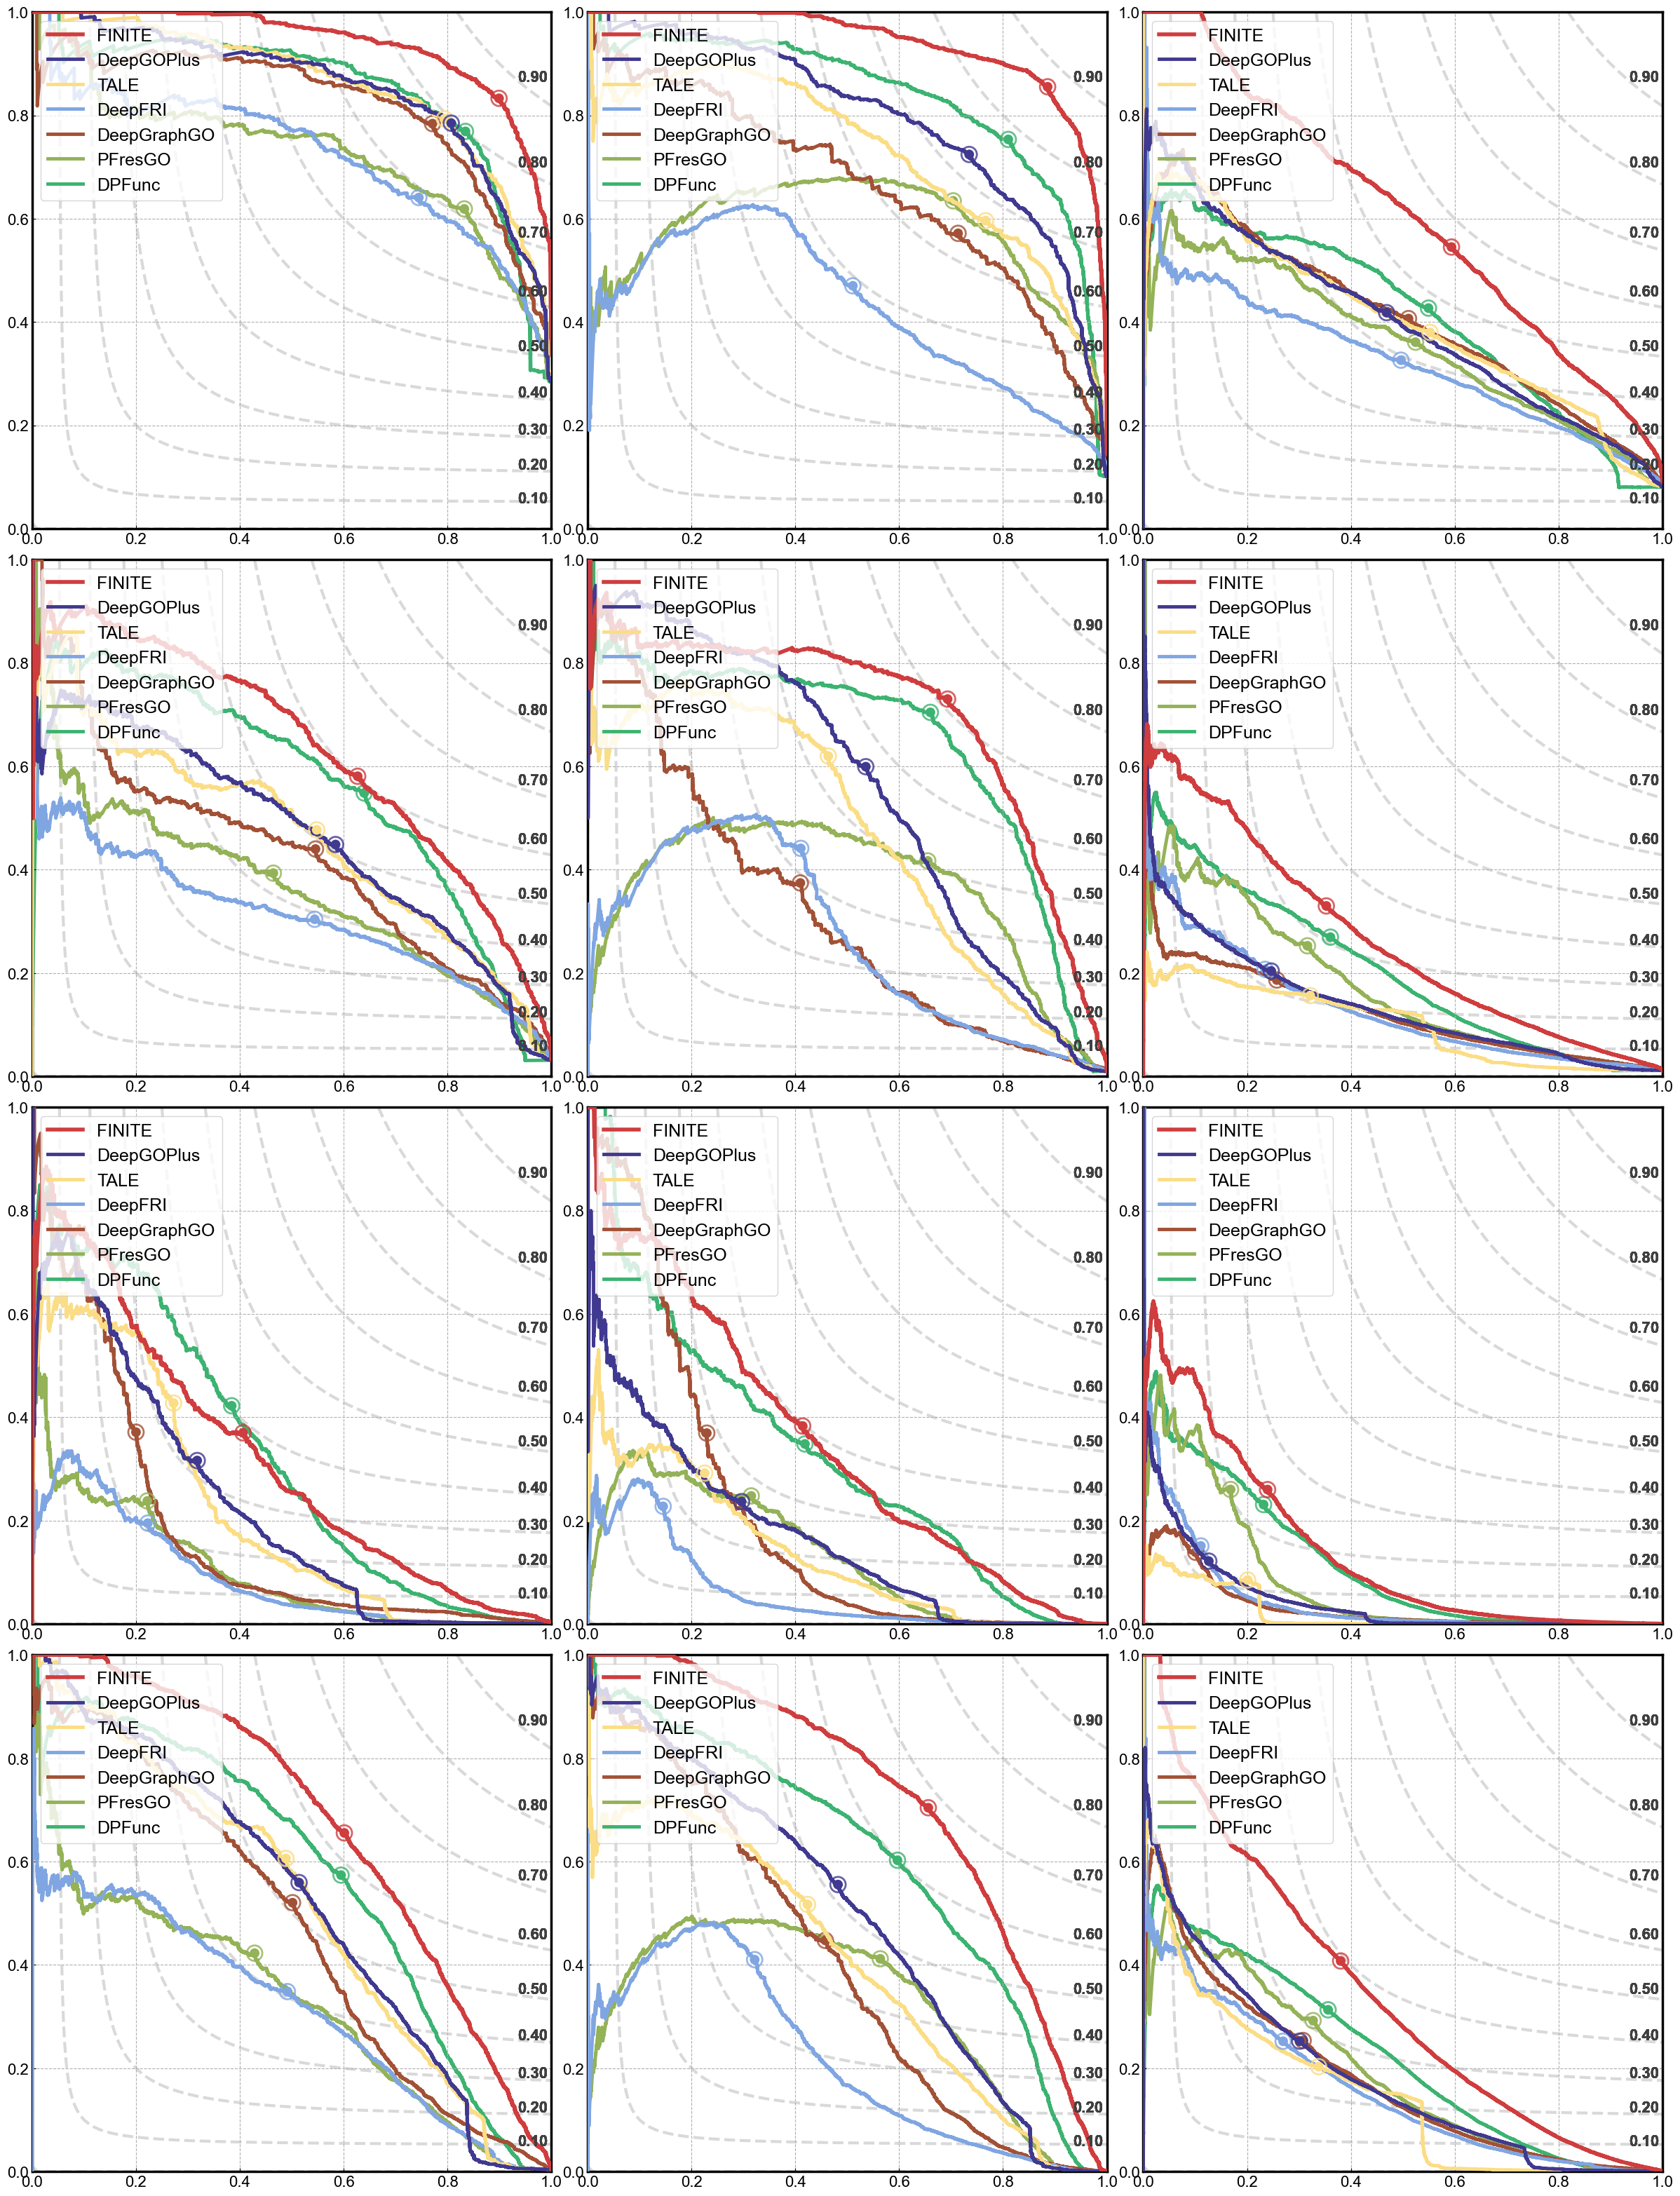

In [30]:
# %%

# Pre-compute common data
n_rows = len(fxcrv_lst)
n_cols = len(fxcrv_lst[0])
X = np.linspace(0, 1., 101)
Y = np.linspace(0, 1., 101)
X, Y = np.meshgrid(X, Y)
Z = (2 * X * Y) / (X + Y + 1e-8)
levels = np.linspace(0.0, 1.0, 11)
# Set up matplotlib parameters once
plt.rcParams.update({
    'figure.figsize': (10 * n_cols, 10 * n_rows),
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 16
})
# Create figure and subplots more efficiently
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 10 * n_rows))
if n_rows == 1 and n_cols == 1:
    axs = [axs]
elif n_rows == 1 or n_cols == 1:
    axs = axs.flatten()
else:
    axs = axs.flatten()
# Set spine properties for all axes at once
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
fig.subplots_adjust(wspace=0.07, hspace=0.06)
# Pre-define constants
label_names = method_names
widths = [4] + [3.5] * (len(label_names) - 1)
colors = ["#CF3D3E", "#403990", "#FBDD85", 
          "#80A6E2", "#A25136", "#94B257",
          "#3CB371", 
        #   "#FF69B4"
          ]
zorders = list(range(len(colors), 0, -1))
text_lst = [f"{x:.2f}" for x in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]]
txt_locs = [(0.935, y) for y in [0.865, 0.7, 0.565, 0.45, 0.345, 0.255, 0.1825, 0.115, 0.05]]
# Main plotting loop
for u, ps_lst in enumerate(fxcrv_lst):
    for v, preds in enumerate(ps_lst):
        ax = axs[u * n_cols + v]
        
        # Add contour once per subplot (not per line)
        ax.contour(X, Y, Z, levels=levels, colors="#D9D9D9", 
                   linestyles="--", linewidths=3, zorder=1)
        
        # Plot all lines for this subplot
        for w, fscr in enumerate(preds):
            # fs, _, curve = fscr
            fs = fscr[0]
            curve = fscr[-1]
            pr, rc, ths = curve
            fx, thres = fs
            # thres = thres_lst[v][w]
            sorted_index = np.argsort(rc)
            rc = rc[sorted_index]
            pr = pr[sorted_index]
            # idx_mask = sorted_index < len(ths)
            # idx_index = sorted_index[np.where(idx_mask)[0]]
            # ths = ths[idx_index]
            # ths = ths[[i for i in sorted_index if i < len(ths)]]
            # print(rc.shape, pr.shape, ths.shape)
            
            # idx = np.argmin(np.abs(ths - thres))  # Get index of threshold closest to selected threshold
            idx = np.argmax((2 * rc * pr) / (rc + pr + 1e-10))  # Get index of maximum F-score
            
            # Use matplotlib plot instead of seaborn lineplot

            ax.plot(rc, pr, label=label_names[w], linewidth=widths[w], 
                   color=colors[w], zorder=zorders[w])
            
            # Combine scatter plots - first the filled circle, then the ring
            ax.scatter(rc[idx], pr[idx], s=100, c=colors[w], 
                      edgecolors='none', zorder=zorders[w]+1)
            ax.scatter(rc[idx], pr[idx], s=250, facecolors='none',
                      edgecolors=colors[w], alpha=0.8, linewidths=2,
                      zorder=zorders[w]+1)
            ax.grid(linestyle="--")
                    
            # Add text annotations
            for txt_idx, loc in enumerate(txt_locs):
                ax.text(*loc, text_lst[txt_idx], 
                        fontdict={"fontsize": 16, "weight": "bold", "color": "#404040"},
                        zorder=max(zorders)+2)
            # Set subplot properties once after all lines are plotted
            legend = ax.legend(loc="upper left", fontsize=18)
            legend.set_zorder(max(zorders)+2)
plt.show()

In [32]:
# %%

saving_path = "/data0/shaojiangyi/pprogo-flg-1/notebooks/perf_analysis/figures/performance_compare-v7.{}"
fig.savefig(saving_path.format("svg"), bbox_inches="tight")
fig.savefig(saving_path.format("png"), dpi=300, bbox_inches="tight")